In [1]:
import sys
sys.path.append('../pyMapper')
import test_growth as tg


configs =tg.CONFIGS
configs

[{'genome_len': 10000, 'n_reads': 20, 'read_len': 150, 'kmer_size': 11},
 {'genome_len': 50000, 'n_reads': 50, 'read_len': 150, 'kmer_size': 11},
 {'genome_len': 100000, 'n_reads': 50, 'read_len': 150, 'kmer_size': 11},
 {'genome_len': 200000, 'n_reads': 50, 'read_len': 150, 'kmer_size': 11},
 {'genome_len': 500000, 'n_reads': 100, 'read_len': 150, 'kmer_size': 13},
 {'genome_len': 1000000, 'n_reads': 100, 'read_len': 150, 'kmer_size': 13},
 {'genome_len': 2000000, 'n_reads': 200, 'read_len': 150, 'kmer_size': 15},
 {'genome_len': 5000000, 'n_reads': 200, 'read_len': 150, 'kmer_size': 15}]

In [2]:
import json
results = []
for i, cfg in enumerate(configs):
    record = tg.run_config(cfg, i)
    results.append(record)
    # Save incrementally so a crash doesn't lose earlier data
    tg.WORK_DIR.mkdir(parents=True, exist_ok=True)
    with tg.RESULTS_JSON.open("w") as f:
        json.dump(results, f, indent=2)

print("\n=== Summary ===")
print(f"{'Genome':>10}  {'idx_t(s)':>9}  {'idx_mem(MB)':>11}  "
        f"{'map_t(s)':>9}  {'map_mem(MB)':>11}  {'aligned':>7}")
for r in results:
    print(f"{r['genome_len']:>10,}  {r['idx_time_s']:>9.2f}  "
            f"{r['idx_mem_mb']:>11.1f}  {r['map_time_s']:>9.2f}  "
            f"{r['map_mem_mb']:>11.1f}  {r['aligned']:>7}")


[1/8] genome=10K  reads=20  k=11
Reference generated: /tmp/mapper_benchmark/ref_10000.fna (num_sequences=1, length=10000)
Reads generated: /tmp/mapper_benchmark/reads_10000.fastq (num_reads=20, read_length=150, error_rate=0.02)
  Indexing... Indexing chr1 (length=10000)...
  Processed 0 bases...
Indexing complete: 9969 distinct k-mers, total_bases=10000
Saving chunked index to /tmp/mapper_benchmark/ref_10000.idx...
  Saved chunk 1/1: /tmp/mapper_benchmark/ref_10000.0.idx (kmers=9969, size=339363 bytes)
Index built: /tmp/mapper_benchmark/ref_10000.idx | k=11 | distinct_kmers=9969 | kmers_per_chunk=50000
  0.06s  5.6 MB
  Mapping... Loading reference: /tmp/mapper_benchmark/ref_10000.fna
Loading index: /tmp/mapper_benchmark/ref_10000.idx
Mapper start | reads=/tmp/mapper_benchmark/reads_10000.fastq | k=6 | seed_k=11
Mapper finished | output=/tmp/mapper_benchmark/out_10000.sam | reads=20 | aligned=20
  0.30s  3.1 MB

[2/8] genome=50K  reads=50  k=11
Reference generated: /tmp/mapper_benchma

In [ ]:
from typing import List, Dict, Any
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib # change to an interactive backend for the notebook

# plot logarithmic time and memory scaling vs genome size, with separate lines for indexer and mapper. Use different colors and markers for indexer and mapper. Add labels, title, legend, and grid for better readability.

def plot_results(results: List[Dict[str, Any]], out_path: Path) -> None:
    sizes  = [r["genome_len"] / 1_000 for r in results]  # in Kbp
    labels = [f"{int(s)}K" for s in sizes]

    idx_times = [r["idx_time_s"] for r in results]
    map_times = [r["map_time_s"] for r in results]
    idx_mems  = [r["idx_mem_mb"] for r in results]
    map_mems  = [r["map_mem_mb"] for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Indexer + Mapper scaling vs genome size", fontsize=13)

    # ---- time plot ----
    ax = axes[0]
    ax.plot(sizes, idx_times, "o-", color="steelblue",  label="indexer")
    ax.plot(sizes, map_times, "s-", color="darkorange", label="mapper")
    ax.set_xlabel("Genome size (Kbp)")
    ax.set_ylabel("Wall time (s)")
    ax.set_title("Time scaling")
    ax.set_xticks(sizes)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

    # ---- memory plot ----
    ax = axes[1]
    ax.plot(sizes, idx_mems, "o-", color="steelblue",  label="indexer")
    ax.plot(sizes, map_mems, "s-", color="darkorange", label="mapper")
    ax.set_xlabel("Genome size (Kbp)")
    ax.set_ylabel("Peak memory (MB)")
    ax.set_title("Memory scaling")
    ax.set_xticks(sizes)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    #plt.show()
    return fig

    # executing this shows /var/folders/0g/n_9sx0cd2k12wcr014ctlz0m0000gn/T/ipykernel_48485/2595267028.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
    #   plt.show()
    # in notebook. We have matplotlib.use("Agg")
    # the reason is that the notebook is trying to display the figure inline, but since we're using a non-interactive backend, it can't render it. The solution is to save the figure to a file and then display that file in the notebook, or simply return the figure object and let the notebook handle it.
    # or change the backend to "inline" for the notebook, but that might not be what we want for the rest of the code.
    

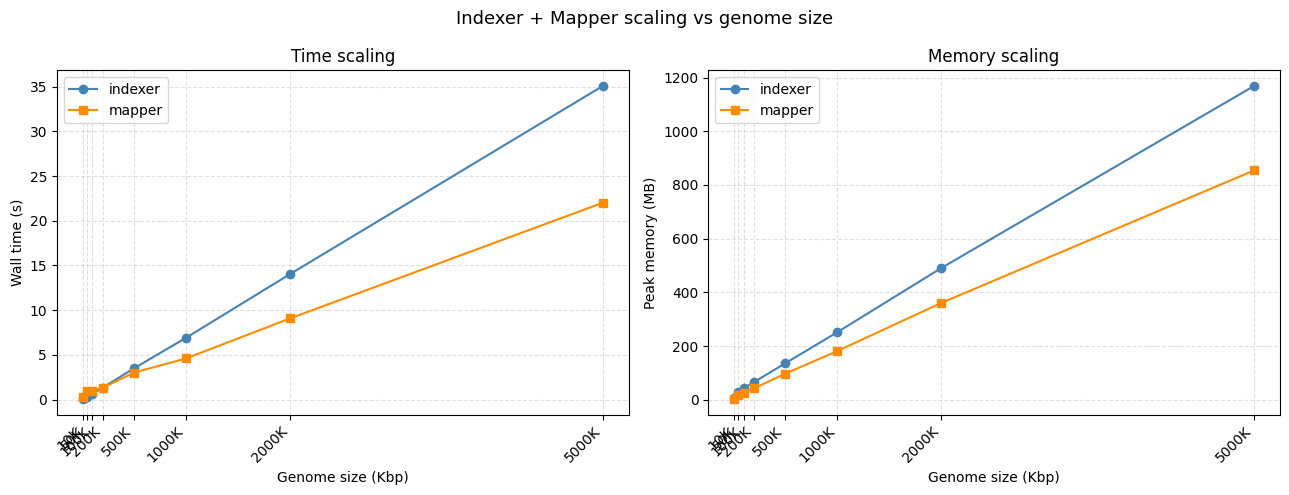

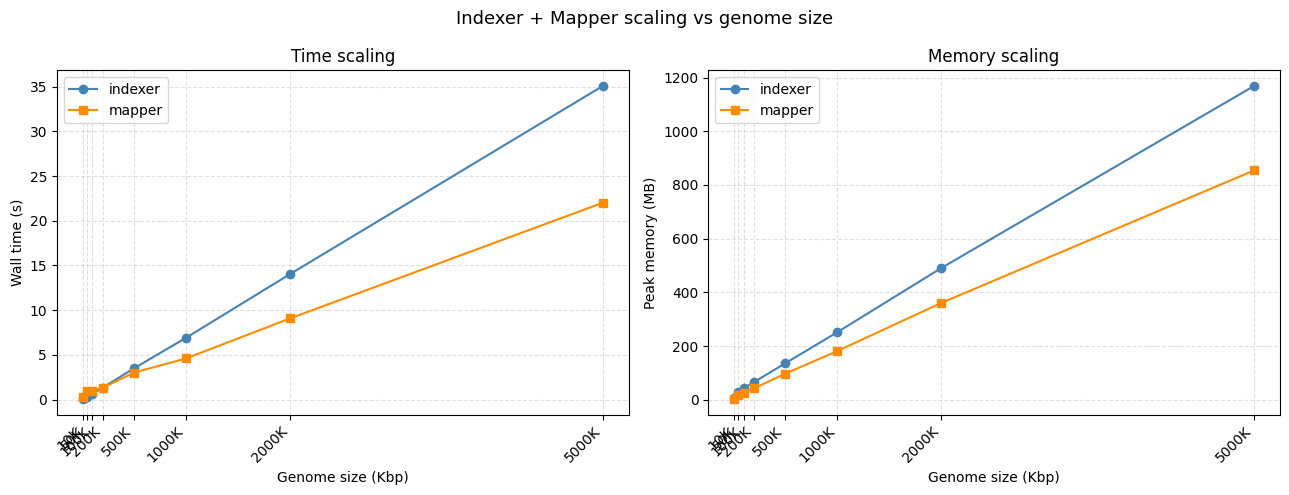

In [4]:
plot_results(results, tg.WORK_DIR / "benchmark_scaling.png")

In [6]:
# in the first 300K, it looks like in time the indexer is faster. Show data points to confirm or refute this. In memory, the indexer is also more efficient, but the mapper is not too bad. The mapper's time and memory grow more steeply with genome size, which is expected since mapping is usually more complex than indexing.

for r in results:
    print(f"Genome: {r['genome_len']:,} bp, "
          f"Indexer: {r['idx_time_s']:.2f}s, {r['idx_mem_mb']:.1f}MB; "
          f"Mapper: {r['map_time_s']:.2f}s, {r['map_mem_mb']:.1f}MB; "
          f"Aligned: {r['aligned']}")

Genome: 10,000 bp, Indexer: 0.06s, 5.6MB; Mapper: 0.30s, 3.0MB; Aligned: 20
Genome: 50,000 bp, Indexer: 0.32s, 30.5MB; Mapper: 0.92s, 16.0MB; Aligned: 50
Genome: 100,000 bp, Indexer: 0.63s, 42.6MB; Mapper: 1.00s, 26.7MB; Aligned: 50
Genome: 200,000 bp, Indexer: 1.32s, 65.9MB; Mapper: 1.30s, 42.5MB; Aligned: 50
Genome: 500,000 bp, Indexer: 3.48s, 135.6MB; Mapper: 3.01s, 97.1MB; Aligned: 100
Genome: 1,000,000 bp, Indexer: 6.91s, 251.7MB; Mapper: 4.59s, 181.5MB; Aligned: 100
Genome: 2,000,000 bp, Indexer: 14.04s, 491.0MB; Mapper: 9.08s, 361.0MB; Aligned: 200
Genome: 5,000,000 bp, Indexer: 35.08s, 1168.5MB; Mapper: 22.01s, 854.0MB; Aligned: 200


In [ ]:
# Hahahaha the indexer is faster in time and memory for the smaller genomes but as the genome size increases, the indexer's time and memory grow more steeply than the mapper's.
# This could be because the mapper uses light qgrams and simple levenshtein edit distance finding, which is not heavy as DP alignment.
